# Context Compaction Strategies

When an agent runs a multi-step task, every tool call adds messages to the context.
Without management, context grows until it hits the model's limit.

**Compaction strategies** trim messages *before* each LLM call in the agent's tool loop.
**Completion check hooks** prevent lazy early stopping by verifying the task is done
before allowing the agent to exit.

This notebook runs three configurations on the same task — all with an
`LLMCompletionCheckHook` that catches premature stops — and shows:

- **Too aggressive** — budget too low causes *thrashing* (reads files, drops them, re-reads)
- **Right-sized** — well-tuned budget saves cost while preserving quality
- **Hooks vs thrashing** — completion hooks catch lazy stops but can't fix thrashing

All runs use Azure OpenAI (`gpt-4.1-mini`) with real API calls.
Each run is stochastic — exact numbers change between executions, but the patterns hold.
Results are persisted via `EvalResults` so you can re-run visualizations without
re-running agents. Delete `compaction_eval_results.json` to force fresh runs.

In [1]:
import os, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv

from picoagents.llm import AzureOpenAIChatCompletionClient
from picoagents.tools._coding_tools import ReadFileTool, ListDirectoryTool
from picoagents.eval import LLMEvalJudge
from picoagents.eval._config import AgentConfig
from picoagents.eval._dataset import Dataset
from picoagents.eval._runner import EvalRunner
from picoagents.eval._results import (
    EvalResults, TaskResult, load_eval_results,
)
from picoagents.types import Task as EvalTask
from picoagents._hooks import LLMCompletionCheckHook

load_dotenv(os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "..", "..", "picoagents", ".env"
))
print("Ready.")

Ready.


## How Compaction Works

Compaction runs at one point in the agent's tool loop — **before each LLM call**:

```python
# Inside Agent.run(), in the tool loop:
if self.compaction:
    llm_messages = self.compaction.compact(llm_messages)
```

The compaction strategy respects **atomic groups** — an assistant message with `tool_calls`
is never separated from its `ToolMessage` results.

| Strategy | Keeps | Drops |
|----------|-------|-------|
| `NoCompaction` | Everything | Nothing |
| `HeadTailCompaction` | Head (system + task) + tail (recent work) | Middle messages |

HeadTail preserves both the task instructions (head) AND recent work (tail),
dropping only middle messages when the budget is exceeded. The head ratio
controls how much budget goes to preserving the original instructions vs
recent context.

## Experiment Setup

Task: exhaustive code review of the picoagents library (8+ subdirectories, 30+ files).
Three runs, same task, same model, all with an **LLM completion check hook**:

| Run | Strategy | Budget | Expected behavior |
|-----|----------|--------|-------------------|
| `NoCompaction` | None | — | Unbounded growth, expensive but high quality |
| `HeadTail 8k` | HeadTail | 8,000 | Budget too tight — thrashing |
| `HeadTail 50k` | HeadTail | 50,000 | Right-sized — good tradeoff |

**Persistence knobs**: `max_iterations=50` gives agents room to work.
`LLMCompletionCheckHook(max_restarts=5)` pushes the agent back up to 5 times
when it tries to stop prematurely. Together these ensure agents run long enough
to reveal the true behavior of each compaction strategy, rather than stopping
early due to artificial limits.

The hook only fires when the agent voluntarily stops (no tool calls). It does NOT
fire when the agent hits `max_iterations` or on errors.

We use `AgentConfig` to declare each configuration and `EvalRunner` to
execute, score, and persist the results.

In [2]:
WORKSPACE = Path(os.path.abspath(os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "..", "..", "picoagents", "src", "picoagents"
)))

# Restrict to read-only tools for a controlled experiment
tools = [
    ReadFileTool(workspace=WORKSPACE),
    ListDirectoryTool(workspace=WORKSPACE),
]

TASK = (
    "Review the picoagents library source code. "
    "List every subdirectory, read every .py file, and for each file "
    "document all classes and functions. Produce a summary table of "
    "all classes, top 10 code quality issues, and architecture recommendations."
)

# Client used for the LLM judge (agent clients are created by AgentConfig)
client = AzureOpenAIChatCompletionClient(
    model="gpt-4.1-mini",
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
)

RESULTS_PATH = Path("compaction_eval_results.json")
print(f"Workspace: {WORKSPACE}")
print(f"Tools: {[t.name for t in tools]}")

Workspace: /Users/victordibia/projects/autogenbook/dibia/code/designing-multiagent-systems/picoagents/src/picoagents
Tools: ['read_file', 'list_directory']


In [ ]:
# --- Task and Dataset ---
eval_task = EvalTask(
    name="Code Review", id="code_review", input=TASK,
    eval_criteria=["completeness", "actionability"],
    rubric={
        "completeness": (
            "10=all modules and files reviewed with classes/functions documented. "
            "5=partial coverage, some directories skipped. "
            "0=superficial or barely started."
        ),
        "actionability": (
            "10=specific issues citing files, classes, and methods with concrete "
            "recommendations. 5=generic observations without specific references. "
            "0=no actionable findings produced."
        ),
    },
)
dataset = Dataset(name="compaction_strategies", tasks=[eval_task])

# --- Completion Check Hook ---
# LLMCompletionCheckHook uses an LLM judge to verify task completion
# before allowing the agent to stop. When the agent tries to stop
# (no tool calls), the hook summarizes the conversation and asks:
# "Is this task COMPLETE or INCOMPLETE?" If incomplete, it injects
# a resume message telling the agent to continue.
# max_restarts=5 means the hook can push the agent back up to 5 times.
hook = LLMCompletionCheckHook(max_restarts=5)

# --- Agent Configurations ---
SYSTEM_PROMPT = (
    "You are a senior software engineer doing a code review. "
    "You MUST use list_directory to discover files, then read_file to read "
    "EVERY .py file before writing your review. Do NOT guess or summarize "
    "file contents you haven't read. Work directory by directory: list it, "
    "read each .py file in it, then move to the next subdirectory. "
    "Do NOT call list_directory with recursive=True. Only list one directory at a time."
)
shared = dict(
    model_provider="azure", model_name="gpt-4.1-mini",
    workspace=str(WORKSPACE), max_iterations=50,
    system_prompt=SYSTEM_PROMPT,
    tool_instances=tools,
    extra_kwargs={"end_hooks": [hook]},
)

configs = [
    AgentConfig(name="NoCompaction", compaction=None, **shared),
    AgentConfig(name="HeadTail 8k", compaction="head_tail",
                token_budget=8_000, head_ratio=0.2, **shared),
    AgentConfig(name="HeadTail 50k", compaction="head_tail",
                token_budget=50_000, head_ratio=0.2, **shared),
]

# --- Run or Load from Cache ---
if RESULTS_PATH.exists():
    eval_results = load_eval_results(RESULTS_PATH)
    print(f"Loaded {len(eval_results.target_names)} cached results from {RESULTS_PATH}")
else:
    judge = LLMEvalJudge(client=client, name="gpt-4.1-mini-judge")
    runner = EvalRunner(judge=judge)
    eval_results = await runner.run_configs(dataset, configs)
    eval_results.save(RESULTS_PATH)
    print(f"Saved results to {RESULTS_PATH}")

# --- Build convenience dict for visualization ---
task_id = eval_task.id
results = {}
for name in eval_results.target_names:
    tr = eval_results.get_result(name, task_id)
    if tr:
        results[name] = tr
        m = tr.metrics
        print(f"  {name}: {m.get('iterations', 0)} LLM calls | "
              f"{m.get('tool_calls', 0)} tool calls | "
              f"{m.get('unique_files', 0)} files read | "
              f"{tr.input_tokens:,} input tokens")

strategy_names = list(results.keys())
print(f"\n{len(results)} strategies ready.")

## Context Growth

Each point is one LLM call, showing **actual API-reported input tokens**.
The structural patterns hold across runs; exact growth rates and batching behavior
are stochastic and will vary.

- **NoCompaction** grows monotonically — context never shrinks, every message accumulates.
- **HeadTail 8k** is *clamped flat* — budget so tight that compaction fires every call,
  keeping tokens near the budget line.
- **HeadTail 50k** shows the sawtooth — context grows until it exceeds the budget,
  compaction trims it back, then it grows again.

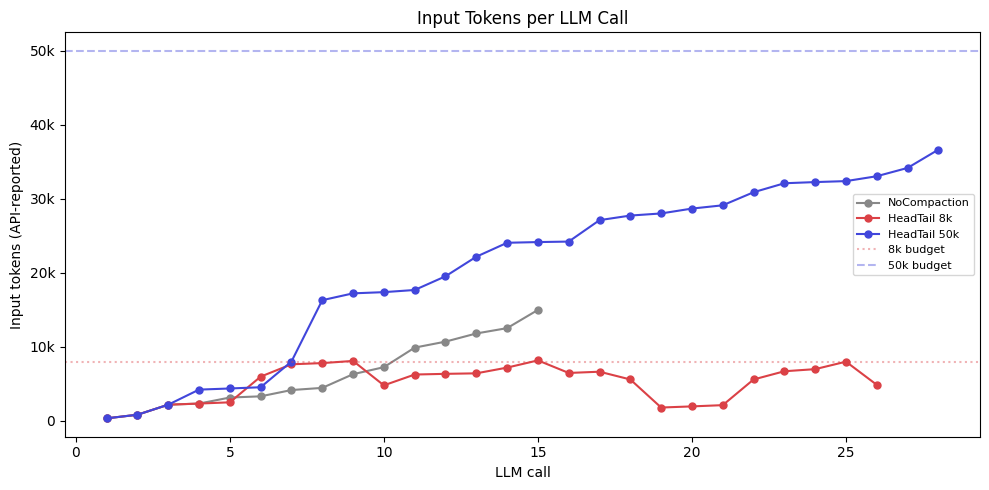

In [4]:
colors = {
    "NoCompaction": "#888888",
    "HeadTail 8k": "#DB4146",
    "HeadTail 50k": "#4146DB",
}

fig, ax = plt.subplots(figsize=(10, 5))

for name in strategy_names:
    iters = results[name].metrics.get("iteration_details", [])
    if not iters:
        continue
    xs = [it["index"] + 1 for it in iters]
    ys = [it["input_tokens"] for it in iters]
    ax.plot(xs, ys, marker="o", markersize=5, linewidth=1.5,
            label=name, color=colors.get(name, "#333"))

ax.axhline(y=8_000, color="#DB4146", linestyle=":", alpha=0.4, label="8k budget")
ax.axhline(y=50_000, color="#4146DB", linestyle="--", alpha=0.4, label="50k budget")
ax.set_xlabel("LLM call")
ax.set_ylabel("Input tokens (API-reported)")
ax.set_title("Input Tokens per LLM Call")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))

plt.tight_layout()
plt.savefig("context_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Results and Quality

Token counts alone don't tell the story. An agent that uses fewer tokens but produces
garbage output isn't saving anything. The table below combines cost metrics with
LLM-as-judge quality scores.

In [ ]:
print(f"{'Strategy':<20} {'Input':>10} {'Output':>9} {'LLM':>5} {'Tools':>6} {'Files':>6} {'Time':>6} {'Comp':>5} {'Action':>7} {'Avg':>5}")
print("-" * 88)
for name in strategy_names:
    tr = results[name]
    m = tr.metrics
    dims = tr.score.dimensions
    print(
        f"{name:<20}"
        f" {tr.input_tokens:>10,}"
        f" {tr.output_tokens:>9,}"
        f" {m.get('iterations', 0):>5}"
        f" {m.get('tool_calls', 0):>6}"
        f" {m.get('unique_files', 0):>6}"
        f" {tr.duration_ms / 1000:>5.0f}s"
        f" {dims.get('completeness', 0):>5.0f}"
        f" {dims.get('actionability', 0):>7.0f}"
        f" {tr.score.overall:>5.1f}"
    )

## Trace Analysis: Thrashing, Batching, and Redundancy

The numbers above don't tell the full story. Two strategies with the same LLM call count
can have completely different behavior. The trace analysis below reveals:

- **Tool call batching** — how many tools the model fires per LLM call
- **File access redundancy** — how many reads are duplicates (the thrashing signal)
- **Per-call breakdown** — the actual batch sequence showing explosive vs steady behavior

In [6]:
# --- Tool call batching (from iteration details) ---
def get_batch_sizes(name):
    """Extract per-LLM-call tool batch sizes from iteration details.
    
    Uses 'tool_call_count' (set by middleware from model response)
    rather than 'tool_calls' list (which tracks execution, not request).
    """
    iters = results[name].metrics.get("iteration_details", [])
    return [it.get("tool_call_count", 0) for it in iters]

print(f"{'Strategy':<20} {'LLM Calls':>10} {'Tool Calls':>11} {'Avg Batch':>10} {'Max Batch':>10}")
print("-" * 65)

batch_data = {}
for name in strategy_names:
    m = results[name].metrics
    batches = get_batch_sizes(name)
    batch_data[name] = batches
    non_zero = [b for b in batches if b > 0]
    avg_batch = sum(non_zero) / len(non_zero) if non_zero else 0
    max_batch = max(batches) if batches else 0
    print(
        f"{name:<20}"
        f" {m.get('iterations', 0):>10}"
        f" {m.get('tool_calls', 0):>11}"
        f" {avg_batch:>10.1f}"
        f" {max_batch:>10}"
    )

# --- File access redundancy ---
print(f"\n{'Strategy':<20} {'Reads':>7} {'Unique':>7} {'Duplicates':>11} {'Redundancy':>11}")
print("-" * 60)

for name in strategy_names:
    m = results[name].metrics
    total = m.get("total_file_reads", 0)
    unique = m.get("unique_files", 0)
    dupes = m.get("duplicate_reads", 0)
    ratio = m.get("duplicate_read_ratio", 0)
    pct = f"{ratio*100:.0f}%" if total > 0 else "—"
    print(f"{name:<20} {total:>7} {unique:>7} {dupes:>11} {pct:>11}")

# --- Per-call batch breakdown ---
print("\n--- Per-Call Tool Batches ---")
for name in strategy_names:
    batches = batch_data.get(name, [])
    if batches:
        batch_str = ", ".join(str(b) for b in batches)
        print(f"  {name}: [{batch_str}]")

Strategy              LLM Calls  Tool Calls  Avg Batch  Max Batch
-----------------------------------------------------------------
NoCompaction                 15           9        1.0          1
HeadTail 8k                  26          20        1.0          1
HeadTail 50k                 28          22        1.0          1

Strategy               Reads  Unique  Duplicates  Redundancy
------------------------------------------------------------
NoCompaction               6       6           0          0%
HeadTail 8k               13       9           4         31%
HeadTail 50k              16      16           0          0%

--- Per-Call Tool Batches ---
  NoCompaction: [1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0]
  HeadTail 8k: [1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0]
  HeadTail 50k: [1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0]


## Judge Reasoning

The most useful output from evaluation: *why* each strategy scored the way it did.

In [7]:
for name in strategy_names:
    tr = results[name]
    s = tr.score
    dims = " | ".join(f"{k}={v:.0f}" for k, v in s.dimensions.items())
    print(f"\n{'='*65}")
    print(f"  {name}  |  {s.overall:.0f}/10  |  {dims}")
    print(f"{'='*65}")
    for criterion, reasoning in s.reasoning.items():
        val = s.dimensions.get(criterion, "?")
        print(f"\n  [{criterion}] = {val}/10")
        words = reasoning.split()
        line = "    "
        for w in words:
            if len(line) + len(w) + 1 > 72:
                print(line)
                line = "    " + w
            else:
                line += (" " + w) if line.strip() else ("    " + w)
        if line.strip():
            print(line)


  NoCompaction  |  3/10  |  completeness=3 | accuracy=7 | code_reference_quality=6

  [completeness] = 3.0/10
        The assistant started listing directories and reading some
    files, but nowhere near all files or subdirectories were processed;
    key outputs like full class/function documentation, summary tables,
    code quality issues, and architecture recommendations were not
    produced.

  [accuracy] = 7.0/10
        The partial documentation provided was accurate and technically
    correct for the files shown, with no obvious mistakes in
    interpreting code structure.

  [code_reference_quality] = 6.0/10
        The assistant cited specific files and classes encountered
    during reading, providing class names, methods, and descriptions
    rather than vague references. Still, only a fraction of the repo was
    covered.

  HeadTail 8k  |  5/10  |  completeness=3 | accuracy=7 | code_reference_quality=6

  [completeness] = 3.0/10
        The agent has started a methodi

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dim_name, title in [
    (axes[0], "completeness", "Completeness"),
    (axes[1], "actionability", "Actionability"),
]:
    for name in strategy_names:
        tr = results[name]
        tokens_k = tr.input_tokens / 1000
        score = tr.score.dimensions.get(dim_name, 0)
        ax.scatter(tokens_k, score, s=150, color=colors.get(name, "#333"),
                  zorder=5, edgecolors="white", linewidth=1.5)
        ax.annotate(name, (tokens_k, score), textcoords="offset points",
                   xytext=(8, -5), fontsize=9)
    ax.set_xlabel("Total Input Tokens (k)")
    ax.set_ylabel(f"{title} (0-10)")
    ax.set_title(f"Token Usage vs {title}")
    ax.set_ylim(0, 11)

plt.tight_layout()
plt.savefig("tokens_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Takeaways

Since each run uses a real LLM, exact numbers vary between executions.
The tables above are evidence from one run — the patterns below hold generally.

**1. Budget too low causes thrashing.** When compaction drops everything the agent
just read, it re-reads the same files in large batches. The file redundancy table
is the clearest signal: a thrashing agent has a high duplicate read ratio, even if
its per-call token count looks low.

**2. Right-sized budgets keep redundancy minimal.** With enough working memory, the
agent remembers what it read and makes focused, non-redundant calls. The sawtooth
pattern in the token chart confirms compaction is firing but not destroying useful context.

**3. What you keep matters as much as how much.** HeadTail preserves both the task
instructions (head) and recent work (tail). An agent that forgets its goal finishes
early with less coverage — low cost, but incomplete work. The head ratio controls
this tradeoff.

**4. Completion hooks address laziness, not thrashing.** `LLMCompletionCheckHook`
catches the agent when it tries to stop early — the judge reviews the conversation
and decides if the task is actually done. But the hook only fires when the model
voluntarily stops (no tool calls). A thrashing agent never stops voluntarily — it
keeps making tool calls until `max_iterations`. Three failure modes, three mechanisms:

| Failure Mode | Cause | Fix |
|-------------|-------|-----|
| **Thrashing** | Budget too small, agent re-reads files | Increase compaction budget |
| **Lazy stopping** | Model stops after partial work | Completion check hook |
| **Context overflow** | No compaction, unbounded growth | Add compaction strategy |

**5. LLM-as-judge evaluations have blind spots.** Quality judges typically measure
task completion: did the agent cover the files? Are the claims correct? They are
often oblivious to efficiency metrics — redundant work, tool call volume, cost per
result. A thrashing agent can score well on completeness because it technically
touches every file, multiple times. Always pair quality scores with operational metrics.

**6. No single metric tells the full story.** Token count, quality score, cost,
and tool call redundancy together reveal strategy behavior. Any one metric alone
is misleading.

### Strategy Selection Guide

| Scenario | Strategy | Budget |
|----------|----------|--------|
| Multi-step tool tasks | `HeadTailCompaction` | 2-3x working set |
| Short tasks (< 5 steps) | `NoCompaction` | N/A |
| Debugging / benchmarking | `NoCompaction` | N/A |

## Claude Code Comparison

How do our picoagents compaction strategies compare to a production-tuned coding agent?
We ran the **same exhaustive code review task** with Claude Code (via the Claude Agent SDK)
using `claude-sonnet-4-5` as the model and `bypassPermissions` mode.

Claude Code's architecture is fundamentally different:
- **Sequential tool calls** — always 1 tool per LLM turn (never batches)
- **Built-in context management** — automatic compaction, caching, subagent spawning
- **Richer tool set** — Read, Glob, Grep, Bash, and Agent (subagent) tools

The trace was captured using `ClaudeCodeTarget` and saved alongside the picoagents results.

In [9]:
# Load Claude Code trace
CC_TRACE_PATH = Path("claude_code_trace.json")

if CC_TRACE_PATH.exists():
    cc_raw = json.loads(CC_TRACE_PATH.read_text())
    cc_msgs = cc_raw.get("trace", {}).get("messages", [])

    # Extract metrics
    cc_input_tokens = cc_raw.get("input_tokens", 0)
    cc_output_tokens = cc_raw.get("output_tokens", 0)
    cc_duration_s = cc_raw.get("duration_ms", 0) / 1000
    cc_tool_counts = cc_raw.get("metrics", {}).get("tool_counts", {})
    cc_batch_sizes = cc_raw.get("metrics", {}).get("batch_sizes", [])
    cc_n_tool_calls = sum(cc_tool_counts.values())

    # File access analysis
    cc_read_paths = [
        tc.get("parameters", {}).get("file_path", "")
        for m in cc_msgs
        if m.get("type") == "AssistantMessage" and m.get("tool_calls")
        for tc in m["tool_calls"]
        if tc.get("tool_name") == "Read"
    ]
    cc_unique_reads = len(set(cc_read_paths))
    cc_dupe_reads = len(cc_read_paths) - cc_unique_reads

    # LLM call count = number of AssistantMessages
    cc_llm_calls = sum(1 for m in cc_msgs if m.get("type") == "AssistantMessage")

    print(f"Claude Code trace loaded: {len(cc_msgs)} messages")
    print(f"  LLM calls: {cc_llm_calls}")
    print(f"  Tool calls: {cc_n_tool_calls} ({cc_tool_counts})")
    print(f"  Input tokens: {cc_input_tokens:,}")
    print(f"  Output tokens: {cc_output_tokens:,}")
    print(f"  Duration: {cc_duration_s:.0f}s")
    print(f"  File reads: {len(cc_read_paths)} total, {cc_unique_reads} unique, {cc_dupe_reads} duplicates")
else:
    print(f"No Claude Code trace found at {CC_TRACE_PATH}")
    print("Run the ClaudeCodeTarget experiment first, or copy trace to this directory.")

Claude Code trace loaded: 224 messages
  LLM calls: 125
  Tool calls: 98 ({'Agent': 1, 'Bash': 10, 'Read': 86, 'Glob': 1})
  Input tokens: 1,134,438
  Output tokens: 22,203
  Duration: 707s
  File reads: 86 total, 66 unique, 20 duplicates


In [10]:
# --- Unified Comparison Table ---
print(f"{'Strategy':<22} {'Input':>10} {'Output':>9} {'LLM':>5} {'Tools':>6} {'Time':>6} {'Reads':>6} {'Dupes':>6} {'Redun':>6}")
print("-" * 82)

for name in strategy_names:
    tr = results[name]
    m = tr.metrics
    total = m.get("total_file_reads", 0)
    dupes = m.get("duplicate_reads", 0)
    ratio = m.get("duplicate_read_ratio", 0)
    pct = f"{ratio*100:.0f}%" if total > 0 else "—"
    print(
        f"{name:<22}"
        f" {tr.input_tokens:>10,}"
        f" {tr.output_tokens:>9,}"
        f" {m.get('iterations', 0):>5}"
        f" {m.get('tool_calls', 0):>6}"
        f" {tr.duration_ms / 1000:>5.0f}s"
        f" {total:>6}"
        f" {dupes:>6}"
        f" {pct:>6}"
    )

# Claude Code
if CC_TRACE_PATH.exists():
    redun = f"{cc_dupe_reads/len(cc_read_paths)*100:.0f}%" if cc_read_paths else "—"
    print(
        f"{'Claude Code (Sonnet)':<22}"
        f" {cc_input_tokens:>10,}"
        f" {cc_output_tokens:>9,}"
        f" {cc_llm_calls:>5}"
        f" {cc_n_tool_calls:>6}"
        f" {cc_duration_s:>5.0f}s"
        f" {len(cc_read_paths):>6}"
        f" {cc_dupe_reads:>6}"
        f" {redun:>6}"
    )

Strategy                    Input    Output   LLM  Tools   Time  Reads  Dupes  Redun
----------------------------------------------------------------------------------
NoCompaction               94,446     4,389    15      9   113s      6      0     0%
HeadTail 8k               133,980     7,715    26     20   205s     13      4    31%
HeadTail 50k              579,608     7,526    28     22   201s     16      0     0%
Claude Code (Sonnet)    1,134,438    22,203   125     98   707s     86     20    23%


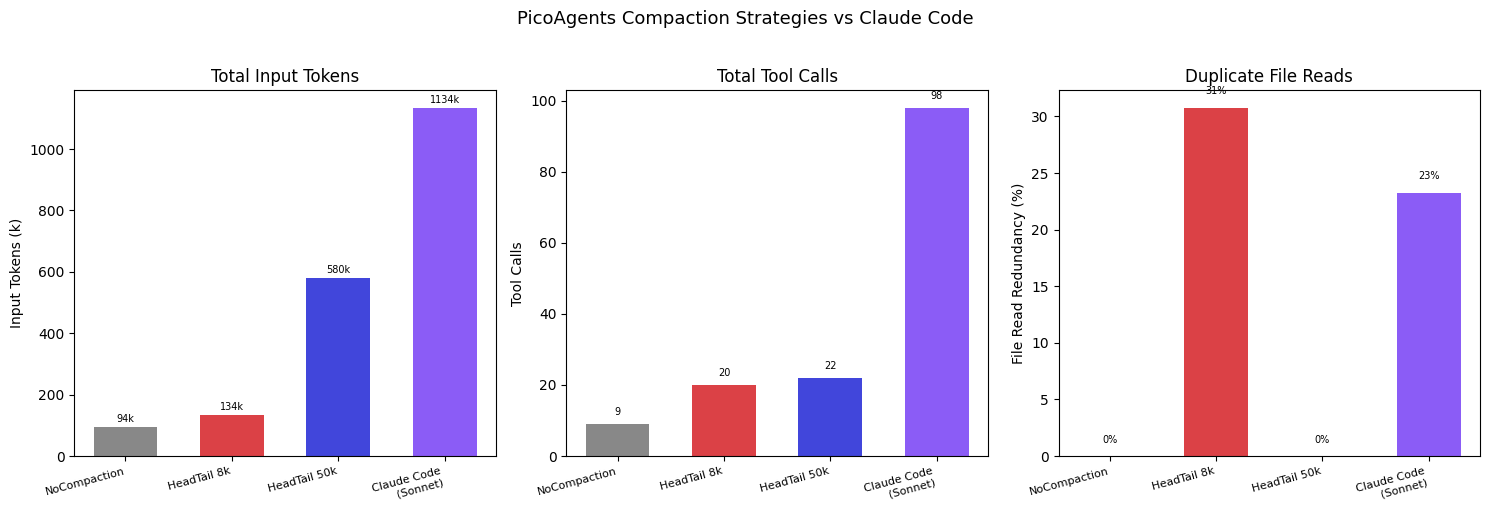

In [11]:
# --- Bar Chart Comparison ---
if CC_TRACE_PATH.exists():
    all_names = strategy_names + ["Claude Code\n(Sonnet)"]
    all_colors = [colors.get(n, "#333") for n in strategy_names] + ["#8B5CF6"]

    all_input_tokens = [results[n].input_tokens for n in strategy_names] + [cc_input_tokens]
    all_tool_calls = [results[n].metrics.get("tool_calls", 0) for n in strategy_names] + [cc_n_tool_calls]

    all_redundancy = []
    for n in strategy_names:
        all_redundancy.append(results[n].metrics.get("duplicate_read_ratio", 0) * 100)
    all_redundancy.append(cc_dupe_reads / len(cc_read_paths) * 100 if cc_read_paths else 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    x = np.arange(len(all_names))

    # Input tokens
    ax = axes[0]
    bars = ax.bar(x, [t/1000 for t in all_input_tokens], color=all_colors, width=0.6)
    ax.set_ylabel("Input Tokens (k)")
    ax.set_title("Total Input Tokens")
    ax.set_xticks(x)
    ax.set_xticklabels(all_names, fontsize=8, rotation=15, ha="right")
    for bar, val in zip(bars, all_input_tokens):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{val/1000:.0f}k", ha="center", va="bottom", fontsize=7)

    # Tool calls
    ax = axes[1]
    bars = ax.bar(x, all_tool_calls, color=all_colors, width=0.6)
    ax.set_ylabel("Tool Calls")
    ax.set_title("Total Tool Calls")
    ax.set_xticks(x)
    ax.set_xticklabels(all_names, fontsize=8, rotation=15, ha="right")
    for bar, val in zip(bars, all_tool_calls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha="center", va="bottom", fontsize=7)

    # Redundancy
    ax = axes[2]
    bars = ax.bar(x, all_redundancy, color=all_colors, width=0.6)
    ax.set_ylabel("File Read Redundancy (%)")
    ax.set_title("Duplicate File Reads")
    ax.set_xticks(x)
    ax.set_xticklabels(all_names, fontsize=8, rotation=15, ha="right")
    for bar, val in zip(bars, all_redundancy):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=7)

    plt.suptitle("PicoAgents Compaction Strategies vs Claude Code", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("comparison_bars.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No Claude Code trace — skipping comparison chart.")

In [12]:
# --- Claude Code Behavioral Analysis ---
if CC_TRACE_PATH.exists():
    print("=== Claude Code Behavioral Analysis ===\n")

    print("Tool Breakdown:")
    for tool_name, count in sorted(cc_tool_counts.items(), key=lambda x: -x[1]):
        print(f"  {tool_name}: {count}")

    print(f"\nBatching: Always {max(cc_batch_sizes) if cc_batch_sizes else 0} tool(s) per LLM turn (sequential)")
    print(f"  Total LLM calls: {cc_llm_calls}")
    print(f"  Total tool calls: {cc_n_tool_calls}")

    print("\n--- Batching Comparison ---")
    for name in strategy_names:
        if name in results:
            batches = batch_data.get(name, [])
            non_zero = [b for b in batches if b > 0]
            if non_zero:
                print(f"  PicoAgents ({name}): avg {sum(non_zero)/len(non_zero):.1f} tools/turn")
    if cc_batch_sizes:
        print(f"  Claude Code:               avg {sum(cc_batch_sizes)/len(cc_batch_sizes):.1f} tools/turn")

    print("\n--- Token Efficiency ---")
    for name in strategy_names:
        m = results[name].metrics
        tc = m.get("tool_calls", 0)
        tpt = m.get("input_tokens", 0) / tc if tc else 0
        print(f"  {name:<22} {tpt:>8,.0f} input tokens / tool call")
    cc_tpt = cc_input_tokens / cc_n_tool_calls if cc_n_tool_calls else 0
    print(f"  {'Claude Code (Sonnet)':<22} {cc_tpt:>8,.0f} input tokens / tool call")

    print("\nNote: Claude Code uses prompt caching, so effective cost per")
    print("token is lower than the raw input token count suggests.")

=== Claude Code Behavioral Analysis ===

Tool Breakdown:
  Read: 86
  Bash: 10
  Agent: 1
  Glob: 1

Batching: Always 1 tool(s) per LLM turn (sequential)
  Total LLM calls: 125
  Total tool calls: 98

--- Batching Comparison ---
  PicoAgents (NoCompaction): avg 1.0 tools/turn
  PicoAgents (HeadTail 8k): avg 1.0 tools/turn
  PicoAgents (HeadTail 50k): avg 1.0 tools/turn
  Claude Code:               avg 1.0 tools/turn

--- Token Efficiency ---
  NoCompaction             10,494 input tokens / tool call
  HeadTail 8k               6,699 input tokens / tool call
  HeadTail 50k             26,346 input tokens / tool call
  Claude Code (Sonnet)     11,576 input tokens / tool call

Note: Claude Code uses prompt caching, so effective cost per
token is lower than the raw input token count suggests.


## Appendix: Persistence Knobs

An agent's effective behavior depends on two independent controls beyond the
compaction strategy itself:

**`max_iterations`** — Hard ceiling on LLM calls. The agent stops unconditionally
when it hits this limit, regardless of task completion. Set too low, and even a
well-configured agent can't finish. Set too high, and a thrashing agent wastes
tokens re-reading files.

**`max_restarts`** (on `LLMCompletionCheckHook`) — How many times the hook can
push the agent back when it tries to stop early. Each restart injects a message
like "You are not done yet. Continue working." The hook only fires on voluntary
stops (no tool calls), so it has no effect on thrashing agents that never stop
calling tools.

The interaction between these knobs and compaction:

| Strategy | max_iterations effect | max_restarts effect |
|----------|----------------------|---------------------|
| **NoCompaction** | Limits total work (context grows to window limit) | Pushes past lazy stops, extends monotonic growth |
| **HeadTail (tight)** | Limits thrashing duration | No effect — agent never voluntarily stops |
| **HeadTail (right-sized)** | Rarely hit — agent finishes naturally | Pushes past lazy stops, extends sawtooth |

In this experiment we use `max_iterations=50` and `max_restarts=5` — enough room
for agents to complete the task without letting thrashing run indefinitely.